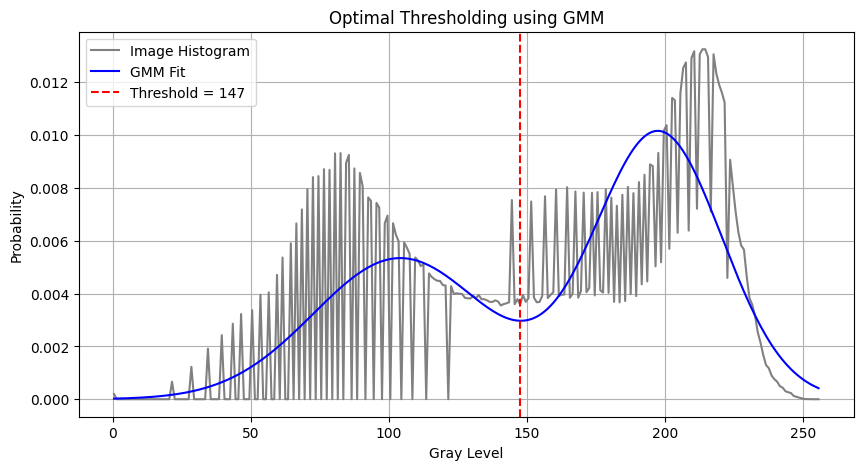

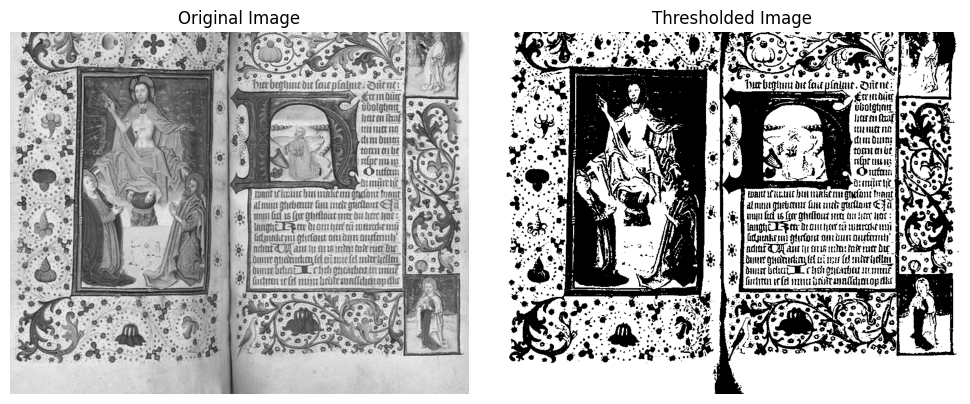

In [24]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture

img = cv2.imread(cv2.samples.findFile("histTest1.png"), cv2.IMREAD_GRAYSCALE)


pixels = img.reshape(-1, 1)


gmm = GaussianMixture(n_components=2, random_state=42)
gmm.fit(pixels)


means = gmm.means_.flatten()
variances = gmm.covariances_.flatten()
weights = gmm.weights_.flatten()


order = np.argsort(means)
means = means[order]
variances = variances[order]
weights = weights[order]


hist, bins = np.histogram(pixels, bins=256, range=(0, 256), density=True)
bin_centers = 0.5 * (bins[:-1] + bins[1:])


gmm_pdf = (
    weights[0] * (1 / np.sqrt(2 * np.pi * variances[0])) * np.exp(-(bin_centers - means[0]) ** 2 / (2 * variances[0]))
    + weights[1] * (1 / np.sqrt(2 * np.pi * variances[1])) * np.exp(-(bin_centers - means[1]) ** 2 / (2 * variances[1]))
)


valley_range = (bin_centers > means[0]) & (bin_centers < means[1])
optimal_thresh = bin_centers[valley_range][np.argmin(gmm_pdf[valley_range])]

_, binary_img = cv2.threshold(img, optimal_thresh, 255, cv2.THRESH_BINARY)

plt.figure(figsize=(10, 5))
plt.plot(bin_centers, hist, label='Image Histogram', color='gray')
plt.plot(bin_centers, gmm_pdf, label='GMM Fit', color='blue')
plt.axvline(optimal_thresh, color='red', linestyle='--', label=f'Threshold = {int(optimal_thresh)}')
plt.xlabel('Gray Level')
plt.ylabel('Probability')
plt.title('Optimal Thresholding using GMM')
plt.legend()
plt.grid(True)
plt.show()



plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(binary_img, cmap='gray')
plt.title('Thresholded Image')
plt.axis('off')
plt.tight_layout()
plt.show()
